In [73]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [74]:
def image_to_array(image_path):
    # Открываем изображение
    img = Image.open(image_path)
    
    # Преобразуем в черно-белый режим 'L'
    img_gray = img.convert('L')
    
    # Преобразуем в массив numpy
    array = np.array(img_gray)
    
    return array


def array_to_image(array, output_path):
    # Проверяем тип данных и преобразуем в uint8, если нужно
    if array.dtype != np.uint8:
        # Если массив содержит числа от 0 до 1, преобразуем в 0-255
        if array.max() <= 1.0:
            array = (array * 255).astype(np.uint8)
        else:
            array = array.astype(np.uint8)
    
    # Создаем изображение из массива
    img = Image.fromarray(array, mode='L')
    
    # Сохраняем изображение
    img.save(output_path)

In [75]:
def plot_image(array, scale=100): 
    plt.figure(figsize=np.array(array.shape[:2:]) // scale)
    plt.imshow(array, cmap='gray')
    plt.axis('off')
    plt.plot()

In [ ]:
img = image_to_array('images/1.jpg')

name = 'k'

plot_image(img)

# Квантование

In [77]:
def quantization(arr):
    return np.round(arr / 255) * 255

In [ ]:
img_out = quantization(img)

plot_image(img_out)

array_to_image(img_out, f'output/{name}_quant.png')

# Добавление шума

## Дизеринг со случайным шумом (random noise)

In [ ]:
noise = 255 * (np.random.random(img.shape) - 0.5)
plot_image(noise)

img_out = quantization(img + noise)

plot_image(img_out)

array_to_image(img_out, f'output/{name}_noise.png')

## Дизеринг с упорядоченным шумом (ordered dithering)

Используем threshhold map

## Простая линейная пороговая карта

In [80]:
d = 10

w, h = img.shape
map = np.zeros_like(img)

for i in range(d): 
    map[::,i::d] = np.ones(map[::,i::d].shape) * i * 255 / d

In [ ]:
plot_image(map)

img_out = (img > map) * 255

plot_image(img_out)

array_to_image(img_out, f'output/{name}_line_ver.png')

In [82]:
d = 10

w, h = img.shape
map = np.zeros_like(img)

for i in range(d): 
    map[i::d,::] = np.ones(map[i::d,::].shape) * i * 255 / d

In [ ]:
plot_image(map)

img_out = (img > map) * 255

plot_image(img_out)

array_to_image(img_out, f'output/{name}_line_hor.png')

## The Bayer matrix

In [84]:
def bayer_matrix(k):

    if k == 0:
        return np.array([[0]])
    
    m = bayer_matrix(k - 1)
    size = m.shape[0]
    result = np.zeros((2 * size, 2 * size), dtype=int)
    
    result[:size, :size] = 4 * m + 0
    result[:size, size:] = 4 * m + 2
    result[size:, :size] = 4 * m + 3
    result[size:, size:] = 4 * m + 1
    
    return result

In [85]:
def full_bayer_map(img, k):

    height, width = img.shape[:2]
    
    # Создаем базовую матрицу Байера
    bayer_base = bayer_matrix(k)
    tile_size = bayer_base.shape[0]
    
    # Вычисляем сколько раз нужно повторить матрицу
    repeats_y = (height + tile_size - 1) // tile_size
    repeats_x = (width + tile_size - 1) // tile_size
    
    # Повторяем матрицу
    bayer_tiled = np.tile(bayer_base, (repeats_y, repeats_x))
    
    # Обрезаем до нужного размера
    bayer_map = bayer_tiled[:height, :width]
    
    return bayer_map

[None, None]

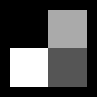

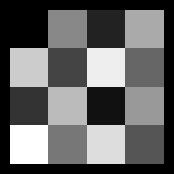

In [86]:
[plot_image(bayer_matrix(i), scale=2) for i in range(1, 3)]

In [ ]:
k = 2

map = full_bayer_map(img, k) * 255 / (2 ** (2*k))

img_out = (img > map) * 255

plot_image(img_out)

array_to_image(img_out, f'output/{name}_bayer.png')

# Mix

In [ ]:
k = 4

map = (full_bayer_map(img, k) + np.random.normal(0, 5, img.shape[:2])) * 255 / (2 ** (2*k))

img_out = (img > map) * 255

plot_image(img_out)

array_to_image(img_out, f'output/{name}_mix.png')

In [89]:
M, N, K = 300, 50, 15

img = np.zeros((M, N))

for i in range(N): 
    for j in range(K):
        img[j*(M//K):(j+1)*(M//K), i] = [j * 255 / (K - 1)] * (M // K)

array_to_image(img, 'images/grad.png')